In [1]:
import anndata as ad
import pandas as pd
from itertools import combinations
import numpy as np

# Number of cores to use
ncores = 64

import sys

import anndata
#from netmap.downstream import final_downstream
from netmap.downstream.edge_selection import *
from netmap.downstream.clustering import *


from netmap.downstream.regulon import *
import warnings

from netmap.utils.data_utils import *
from netmap.utils.tf_utils import *
from netmap.utils.netmap_config import NetmapConfig

from netmap.model.train_model import create_model_zoo
from netmap.grn.inferrence import inferrence, inferrence_model_wise
from netmap.masking.internal import *
from netmap.masking.external import *


import scipy.sparse as scs


import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt

import yaml


def save_clustering_score_to_yaml(analysis_output_dir, score):
    data = {'clustering_score': float(score) }
    with open(op.join(analysis_output_dir, 'clustering_score.yaml'), 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

In [2]:
collectri = pd.read_csv('/data_nfs/og86asub/netmap/netmap-evaluation/data/input_network/collectri.tsv', sep = '\t')
adata_raw = sc.read_h5ad('/data_nfs/og86asub/netmap/netmap-evaluation/data/blood/reprocessed/cd8tcells_extra_genes.h5ad')
experiment_name = 'cd8_tcells_extra_genes'
output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/cd8_usecase_low_ui/"
var = pd.read_csv(op.join(output_dir, f'{experiment_name}_var.tsv'))
obs = pd.read_csv(op.join(output_dir, f'{experiment_name}_obs.tsv'))
grn_adata = ad.AnnData(shape = (obs.shape[0], var.shape[0]), var = var, obs = obs)

In [3]:
analysis_output_dir = f"/data_nfs/og86asub/netmap/netmap-evaluation/results/case_studies/blood/analysis/{experiment_name}"
os.makedirs(analysis_output_dir, exist_ok=True)

In [4]:
analysis_output_dir = op.join(output_dir, )
grn_output_dir = Path(op.join(output_dir, "grn"))

## load data
Get the top 10 percent of the egdes by global weight, to perform the clustering on. These will be discarded again, and replaced by better edges.

In [5]:
grn_adata = retrieve_top_edges(grn_adata, grn_output_dir, percentage=0.1, inplace=True)
grn_adata.var = grn_adata.var.set_index('index')


## Cluster the anndata object with the gene expression data.

In [6]:
sc.tl.pca(adata_raw, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(adata_raw, n_neighbors = 50)
sc.tl.umap(adata_raw, n_components =50)
sc.tl.leiden(adata_raw, resolution=0.15)


## Embedd data using standard embedding to get the clustering
Here you can set a higher resolution, it will map clusters accordingly. 
These clusters will be selected to find edges which are 'highly expressed' in a local neighborhood.

In [7]:
sc.tl.pca(grn_adata, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata, n_neighbors = 50)
sc.tl.umap(grn_adata, n_components =50)
sc.tl.tsne(grn_adata)
sc.tl.leiden(grn_adata, resolution=0.8)

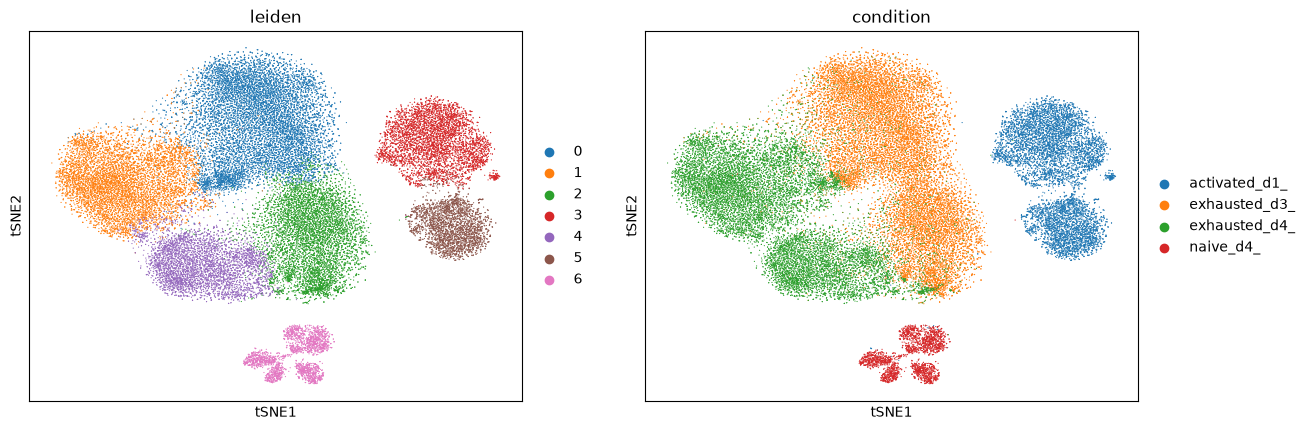

In [8]:

with plt.rc_context(): 
    sc.pl.tsne(grn_adata, color = ['leiden', 'condition'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")

## Check how well the clustering is concordant with the gene expression clustering
The score indicated how many cells are 'correctly' assigned between the gene expression clustering and the gene expression clustering.
It varies between 1/n_clusters (random assignment) and 1 (perfect identical clustering.)

In [9]:
print("\nClustering Score Evaluation")
score, mapping = unify_group_labelling(  adata_raw,grn_adata, 'condition', 'leiden', True)
print(score)
save_clustering_score_to_yaml(analysis_output_dir, score)


Clustering Score Evaluation
0.9521472680739158


In [10]:
# Add the gene expression based clustering back to the GEX expression object.
adata_raw.obs['celltype_remapped'] = grn_adata.obs['leiden_remap'].values


## Make a new anndata object, loading more interesting edges per cluster

### Load only viable edges which have reasonable expression of the base edges.
We previously clustered the data into smaller groups, now we are loading edges which are interesting in that group. We only load edges where the underlying pairs of genes are expressed in a minimum percentage of cells together.

Note: The cluster column you select here should remain consistent throughout the notebook.

In [11]:
grn_adata2 = ad.AnnData(shape=(obs.shape[0], var.shape[0]), var=var, obs=obs)
grn_adata2.var = grn_adata2.var.set_index("index")
grn_adata2.obs = grn_adata.obs

add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts', mask_data=False )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.5)


In [12]:

index_list = np.where(grn_adata2.var["candidate_edge"])[0]
grn_adata2 = retrieve_edges_by_index(grn_adata2, grn_output_dir, index_list)

grn_adata2.obsm["X_pca"] = grn_adata.obsm["X_pca"]
grn_adata2.obsm["X_umap"] = grn_adata.obsm["X_umap"]
grn_adata2.obsm["X_tsne"] = grn_adata.obsm["X_tsne"]


cluster_column = 'leiden'
add_neighbourhood_expression_mask(adata_raw, grn_adata2, strict=False, layer = 'counts' )
grn_adata2 = add_cluster_based_candidate_edges(grn_adata2, threshold=0.01, cluster_column=cluster_column)


In [13]:
# get informative eges and replace the anndata object with the new data.
# Choose inplace =true to update the edges 
index_list = np.where(grn_adata2.var['candidate_edge'])[0]
grn_adata2 = retrieve_edges_by_index(grn_adata2, grn_output_dir, index_list, inplace=True)

## Recluster the data
Now that we have loaded reliable edges, we can recluster the data to see if we are still in line with the gene expression clustering.

In [14]:
sc.tl.pca(grn_adata2, svd_solver = 'randomized', zero_center = False)
sc.pp.neighbors(grn_adata2, n_neighbors = 50)
sc.tl.umap(grn_adata2, n_components =50)
sc.tl.tsne(grn_adata2)

In [15]:
sc.tl.leiden(grn_adata2, resolution=0.15)

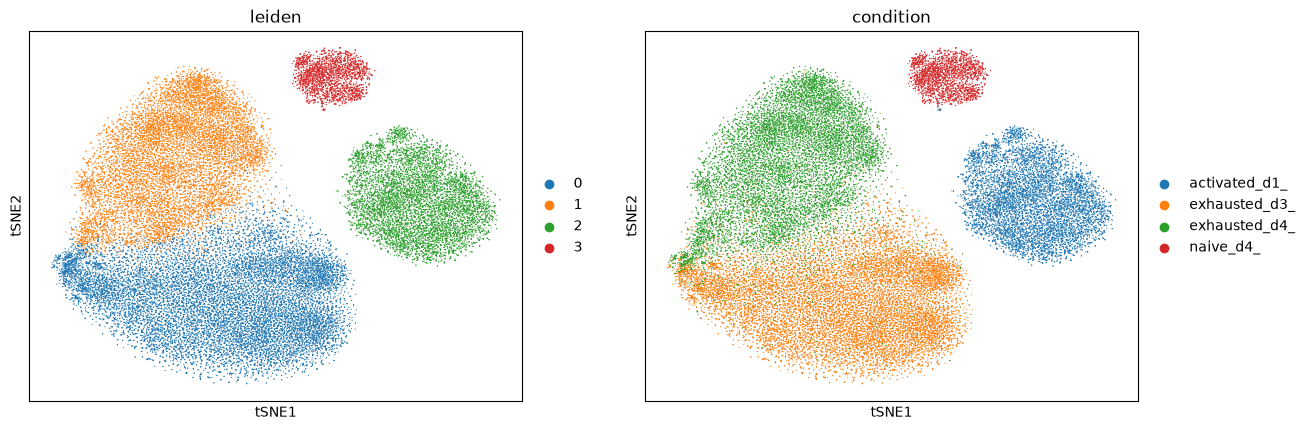

In [16]:

with plt.rc_context(): 
    sc.pl.tsne(grn_adata2, color = ['leiden', 'condition'], show=False)
    plt.savefig(op.join(analysis_output_dir, 'grn_clustering_comparison_tsne.pdf'), bbox_inches="tight")
plt.show()

In [17]:
cross_tab = pd.crosstab( grn_adata2.obs['condition'],  grn_adata2.obs['leiden_remap'])
cross_tab

leiden_remap,activated_d1_,exhausted_d3_,exhausted_d4_,naive_d4_
condition,,,,
activated_d1_,8630,10,1,24
exhausted_d3_,1,16901,299,0
exhausted_d4_,3,1692,12341,3
naive_d4_,0,2,3,2679


## Add an external annotation GRN if desired
Make sure that the gene names in the GRN are compatible with the gene names in the data.

In [18]:
 grn_adata2 = add_external_grn(grn_ad= grn_adata2, external_grn=collectri,name_grn='collectri')

## Create regulon signatures by selecting the unique top edges per cluster

In [19]:
tp = 20 # Choose 20 targets per cluster
min_reg_size = 3 #Regulon size lower bound

keep_edges = select_top_edges(gene_inter_adata= grn_adata2, adata=adata_raw, top_per_source=tp, col_cluster=cluster_column, min_reg_size=min_reg_size, verbose=True)
all_regulons = make_cluster_regulon_dataframe(keep_edges)
# Aggregate the regulons by summing over the edges.


Selecting targets for cluster: 0


Selecting targets for cluster: 1
Selecting targets for cluster: 2
Selecting targets for cluster: 3


In [20]:
regus = aggregate_edges(keep_edges,  grn_adata2, key='unique')
# Make a signature anndata object with the aggregated regulon dataframe
all_signatures = ad.AnnData(X = regus, obs = adata_raw.obs, obsm = adata_raw.obsm)
all_signatures.obs[cluster_column] =  grn_adata.obs[cluster_column].values
all_signatures.var['regulon_name'] = all_signatures.var.index.values

# Run differential testing to get the top signatures per group
sc.tl.rank_genes_groups(all_signatures, cluster_column, method='wilcoxon', key_added = "wilcoxon")


## Save your objects if desired.

In [21]:
grn_adata2.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_processed.h5ad'))
all_signatures.write_h5ad(op.join(analysis_output_dir, f'{experiment_name}_signatures.h5ad'))